## Step 1: Install and imports

In [1]:
!pip install -q torch pandas numpy scikit-learn matplotlib seaborn

## Step 2: Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from google.colab import files

## Step 3: Upload CSVs

In [4]:
uploaded = files.upload()

cnn_df = pd.read_csv("cnn_embeddings_daily.csv")
nlp_df = pd.read_csv("reef_embeddings_scibert_scivocab_uncased_2018_2025.csv")

cnn_df["date"] = pd.to_datetime(cnn_df["date"])
cnn_df["period"] = cnn_df["date"].dt.strftime("%Y-%m")

print("CNN shape:", cnn_df.shape)
print("NLP shape:", nlp_df.shape)
print("CNN labels:", sorted(cnn_df["label"].unique()))

Saving reef_embeddings_scibert_scivocab_uncased_2018_2025.csv to reef_embeddings_scibert_scivocab_uncased_2018_2025.csv
CNN shape: (2642, 260)
NLP shape: (192, 770)
CNN labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Step 4: Prepare seasonal NLP context

In [5]:
# Remap labels: 5 -> 3 classes
LABEL_MAP = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
cnn_df["label"] = cnn_df["label"].map(LABEL_MAP)
print("Remapped label distribution:")
print(cnn_df["label"].value_counts().sort_index())

# Season helpers
def get_season(month):
    if month in [12, 1, 2]:  return "Summer"
    elif month in [3, 4, 5]: return "Autumn"
    elif month in [6, 7, 8]: return "Winter"
    else:                     return "Spring"

def get_season_year(date):
    season = get_season(date.month)
    year   = date.year - 1 if (season == "Summer" and date.month == 12) else date.year
    return season, year

cnn_df["season"], cnn_df["season_year"] = zip(*cnn_df["date"].apply(get_season_year))

# Average North + Central NLP per month -> seasonal
nlp_emb_cols = [c for c in nlp_df.columns if c.startswith("emb_")]
nlp_monthly  = nlp_df.groupby("period")[nlp_emb_cols].mean().reset_index()
nlp_monthly["year"]        = nlp_monthly["period"].str[:4].astype(int)
nlp_monthly["month"]       = nlp_monthly["period"].str[5:].astype(int)
nlp_monthly["season"]      = nlp_monthly["month"].apply(get_season)
nlp_monthly["season_year"] = nlp_monthly.apply(
    lambda r: r["year"] - 1 if (r["season"] == "Summer" and r["month"] == 12) else r["year"],
    axis=1
)

nlp_monthly = nlp_monthly[nlp_monthly["season_year"].between(2018, 2025)]
nlp_seasonal = nlp_monthly.groupby(["season", "season_year"])[nlp_emb_cols].mean().reset_index()
nlp_seasonal.columns = ["season", "season_year"] + [f"nlp_{c}" for c in nlp_emb_cols]

print(f"Seasonal NLP shape: {nlp_seasonal.shape}  (should be 32)")

cnn_df = cnn_df.merge(nlp_seasonal, on=["season", "season_year"], how="left")
nlp_ctx_cols = [c for c in cnn_df.columns if c.startswith("nlp_")]
cnn_df[nlp_ctx_cols] = cnn_df[nlp_ctx_cols].fillna(0.0)

print(f"Days with NLP vector: {(cnn_df[nlp_ctx_cols[0]] != 0.0).sum()} / {len(cnn_df)}")

Remapped label distribution:
label
0    703
1    956
2    983
Name: count, dtype: int64
Seasonal NLP shape: (32, 770)  (should be 32)
Days with NLP vector: 2611 / 2642


## Step 5: Normalise embeddings

In [6]:
cnn_emb_cols = [f"emb_{i}" for i in range(256)]
nlp_ctx_cols = [c for c in cnn_df.columns if c.startswith("nlp_")]

train_mask = cnn_df["split"] == "train"
test_mask  = cnn_df["split"] == "test"

scaler_cnn = StandardScaler()
scaler_nlp = StandardScaler()

cnn_df.loc[train_mask, cnn_emb_cols] = scaler_cnn.fit_transform(cnn_df.loc[train_mask, cnn_emb_cols])
cnn_df.loc[test_mask,  cnn_emb_cols] = scaler_cnn.transform(cnn_df.loc[test_mask,  cnn_emb_cols])

cnn_df.loc[train_mask, nlp_ctx_cols] = scaler_nlp.fit_transform(cnn_df.loc[train_mask, nlp_ctx_cols])
cnn_df.loc[test_mask,  nlp_ctx_cols] = scaler_nlp.transform(cnn_df.loc[test_mask,  nlp_ctx_cols])

print("Embeddings normalised.")
print(f"CNN dims: {len(cnn_emb_cols)}  NLP dims: {len(nlp_ctx_cols)}")

Embeddings normalised.
CNN dims: 256  NLP dims: 768


## Step 6: Build sequences

30 consecutive days of CNN embeddings + seasonal NLP context vector for that window's month.

In [7]:
SEQ_LEN = 30

train_df = cnn_df[cnn_df["split"] == "train"].sort_values("date").reset_index(drop=True)
test_df  = cnn_df[cnn_df["split"] == "test"].sort_values("date").reset_index(drop=True)

def build_sequences(df, seq_len):
    X_cnn, X_nlp, y = [], [], []
    for i in range(len(df) - seq_len + 1):
        window = df.iloc[i:i+seq_len]
        X_cnn.append(window[cnn_emb_cols].values)
        X_nlp.append(window[nlp_ctx_cols].values[-1])
        y.append(window["label"].values[-1])
    return (
        np.array(X_cnn, dtype=np.float32),
        np.array(X_nlp, dtype=np.float32),
        np.array(y,     dtype=np.int64)
    )

X_cnn_train, X_nlp_train, y_train = build_sequences(train_df, SEQ_LEN)
X_cnn_test,  X_nlp_test,  y_test  = build_sequences(test_df,  SEQ_LEN)

print(f"Train: CNN {X_cnn_train.shape}  NLP {X_nlp_train.shape}  Labels {y_train.shape}")
print(f"Test : CNN {X_cnn_test.shape}   NLP {X_nlp_test.shape}   Labels {y_test.shape}")

Train: CNN (1886, 30, 256)  NLP (1886, 768)  Labels (1886,)
Test : CNN (698, 30, 256)   NLP (698, 768)   Labels (698,)


## Step 7: Dataset and DataLoader

In [8]:
class SeqFusionDataset(Dataset):
    def __init__(self, X_cnn, X_nlp, y):
        self.X_cnn = torch.tensor(X_cnn)
        self.X_nlp = torch.tensor(X_nlp)
        self.y     = torch.tensor(y)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X_cnn[idx], self.X_nlp[idx], self.y[idx]

train_ds = SeqFusionDataset(X_cnn_train, X_nlp_train, y_train)
test_ds  = SeqFusionDataset(X_cnn_test,  X_nlp_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Train: {len(train_ds)}  |  Test: {len(test_ds)}")

Train: 1886  |  Test: 698


## Step 8: Cross-attention fusion model

- CNN sequence (30 days × 256-dim) → positional encoding → Transformer self-attention
- SciBERT NLP vector (768-dim) → projected to 256-dim → Key + Value
- Cross-attention: each CNN day queries NLP context
- Last token → classifier → 3 classes

In [9]:
CNN_DIM    = 256
NLP_DIM    = 768   # SciBERT output dim
HIDDEN_DIM = 256
NUM_HEADS  = 4
NUM_CLASSES = 3

class CrossAttentionFusion(nn.Module):
    def __init__(self, cnn_dim=CNN_DIM, nlp_dim=NLP_DIM,
                 hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()

        self.nlp_proj = nn.Sequential(
            nn.Linear(nlp_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.cnn_proj  = nn.Linear(cnn_dim, hidden_dim)
        self.pos_enc   = nn.Embedding(100, hidden_dim)

        self.self_attn = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout, batch_first=True
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, cnn_seq, nlp_vec):
        B, T, _ = cnn_seq.shape
        cnn_h   = self.cnn_proj(cnn_seq)
        positions = torch.arange(T, device=cnn_seq.device).unsqueeze(0)
        cnn_h   = cnn_h + self.pos_enc(positions)
        cnn_h   = self.self_attn(cnn_h)
        nlp_h   = self.nlp_proj(nlp_vec).unsqueeze(1)
        fused, _ = self.cross_attn(query=cnn_h, key=nlp_h, value=nlp_h)
        fused   = self.norm(fused + cnn_h)
        out     = fused[:, -1, :]
        return self.classifier(out)

## Step 9: Training

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

label_counts = np.bincount(y_train)
class_weights = torch.tensor(
    1.0 / label_counts * label_counts.sum() / len(label_counts),
    dtype=torch.float32
).to(device)
print("Class weights:", class_weights.cpu().numpy().round(3))

model     = CrossAttentionFusion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS, PATIENCE = 100, 15
best_val_acc, patience_ctr, best_state = 0.0, 0, None
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for cnn_b, nlp_b, labels in train_loader:
        cnn_b, nlp_b, labels = cnn_b.to(device), nlp_b.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(cnn_b, nlp_b)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for cnn_b, nlp_b, labels in test_loader:
            cnn_b, nlp_b, labels = cnn_b.to(device), nlp_b.to(device), labels.to(device)
            logits = model(cnn_b, nlp_b)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)

    acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    val_accs.append(acc)

    if acc > best_val_acc:
        best_val_acc = acc
        patience_ctr = 0
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {train_losses[-1]:.4f} | Val Acc: {acc:.4f} | Best: {best_val_acc:.4f} | Patience: {patience_ctr}/{PATIENCE}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.4f}")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model (val acc: {best_val_acc:.4f})")

Device: cuda
Class weights: [1.088 0.95  0.973]
Epoch  10 | Loss: 0.1746 | Val Acc: 0.8739 | Best: 0.8883 | Patience: 3/15
Epoch  20 | Loss: 0.1244 | Val Acc: 0.8711 | Best: 0.8883 | Patience: 13/15

Early stopping at epoch 22. Best val acc: 0.8883

Restored best model (val acc: 0.8883)


## Step 10: Evaluate

=== SciBERT Cross-Attention Fusion ===
              precision    recall  f1-score   support

   No Stress       0.82      0.94      0.88       125
    Moderate       0.96      0.77      0.85       283
      Severe       0.87      0.99      0.92       290

    accuracy                           0.89       698
   macro avg       0.88      0.90      0.88       698
weighted avg       0.90      0.89      0.89       698



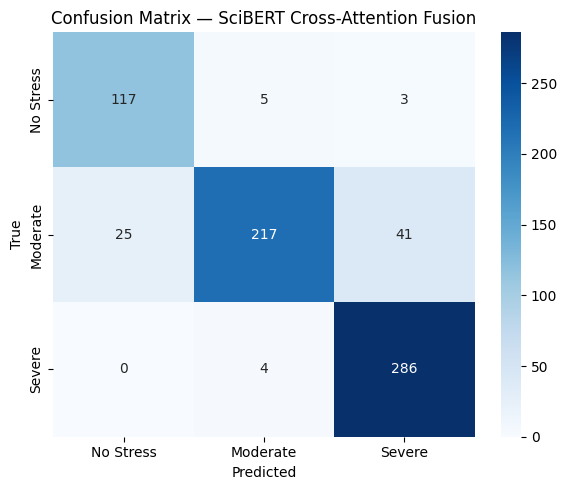

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for cnn_b, nlp_b, labels in test_loader:
        cnn_b, nlp_b = cnn_b.to(device), nlp_b.to(device)
        logits = model(cnn_b, nlp_b)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("=== SciBERT Cross-Attention Fusion ===")
print(classification_report(all_labels, all_preds,
      target_names=["No Stress", "Moderate", "Severe"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Stress","Moderate","Severe"],
            yticklabels=["No Stress","Moderate","Severe"])
plt.title("Confusion Matrix — SciBERT Cross-Attention Fusion")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_scibert.png", dpi=150)
plt.show()

## Step 11: Training curves

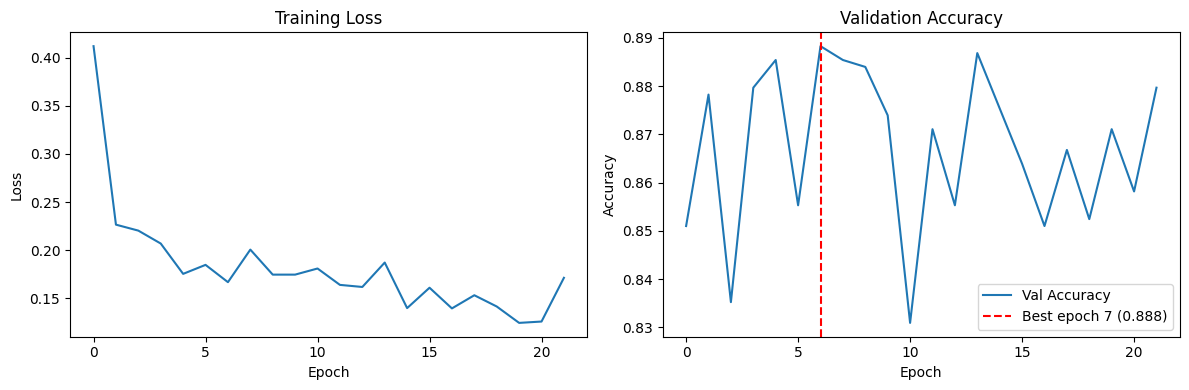

Best epoch: 7  |  Best val acc: 0.8883


In [12]:
best_epoch = int(np.argmax(val_accs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(val_accs, label="Val Accuracy")
ax2.axvline(best_epoch, color="red", linestyle="--",
            label=f"Best epoch {best_epoch+1} ({best_val_acc:.3f})")
ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/training_curves_scibert.png", dpi=150)
plt.show()
print(f"Best epoch: {best_epoch+1}  |  Best val acc: {best_val_acc:.4f}")

## Step 12: Save and download

In [13]:
torch.save(model.state_dict(), "/content/scibert_crossattn_fusion.pth")

from google.colab import files as colab_files
colab_files.download("/content/scibert_crossattn_fusion.pth")
colab_files.download("/content/confusion_matrix_scibert.png")
colab_files.download("/content/training_curves_scibert.png")
print("Done.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
